# Bavian Resultater og Fortolkning

Denne notebook samler og fortolker jeg resultaterne fra notebook 03–06 og laver yderligere analyser direkte på bavian-data.
Så jeg kommer ind på følgende i denne notebook:

1. Overblik over alle populationer (SFS + heterozygositet)
2. Model-fit: forventet vs. observeret SFS per population
3. Two-island model — Eastern yellow vs. Kinda
4. IM-model — Southern olive vs. Eastern yellow  
5. Sammenligning af split-tider med Sørensen et al. (2023)
6. Tajima's D — test for neutral evolution
7. Theta-estimater på tværs af populationer

## Indlæs alle gemte data 

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior,
    Adam, ExpStepSize, StateIndexer, Property, set_log_level,
)
set_log_level("WARNING")

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
%config InlineBackend.figure_format = 'svg'
from functools import partial
from itertools import combinations_with_replacement
from vscodenb import set_vscode_theme, vscode_theme
from pathlib import Path


all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)
set_vscode_theme()
sns.set_palette("tab10")

set_log_level("WARNING")

MUT_RATE = 0.9e-8
GEN_TIME = 11
OUT_DIR = Path("output")
OUT_DIR.mkdir(exist_ok=True)

print("Imports OK")

Imports OK


In [2]:
# Indlæs alle gemte data 
pi_df = pd.read_csv(OUT_DIR / "pi_per_population.csv", index_col=0)
df_ye = pd.read_csv(OUT_DIR / "derived_counts_yellow_east.csv")
df_ki = pd.read_csv(OUT_DIR / "derived_counts_kinda.csv")
df_os = pd.read_csv(OUT_DIR / "derived_counts_olive_south.csv")
df_yw = pd.read_csv(OUT_DIR / "derived_counts_yellow_west.csv")
df_og = pd.read_csv(OUT_DIR / "derived_counts_olive_gog.csv")

sfs_ye = pd.read_csv(OUT_DIR / "sfs_folded_yellow_east.csv",  index_col=0).squeeze()
sfs_ki = pd.read_csv(OUT_DIR / "sfs_folded_kinda.csv",         index_col=0).squeeze()
sfs_os = pd.read_csv(OUT_DIR / "sfs_folded_olive_south.csv",  index_col=0).squeeze()
sfs_yw = pd.read_csv(OUT_DIR / "sfs_folded_yellow_west.csv",  index_col=0).squeeze()
sfs_og = pd.read_csv(OUT_DIR / "sfs_folded_olive_gog.csv",    index_col=0).squeeze()

pop_names = {
    "Eastern yellow (Mikumi)": (df_ye, sfs_ye, "C1"),
    "Kinda":                   (df_ki, sfs_ki, "C2"),
    "Southern olive":          (df_os, sfs_os, "C3"),
    "Western yellow (Mahale)": (df_yw, sfs_yw, "C4"),
    "Olive gog":               (df_og, sfs_og, "C5"),
}
print("Data indlæst OK")
print(pi_df.round(6))

Data indlæst OK
                               pi
Eastern yellow (Mikumi)  0.002584
Kinda                    0.002861
Southern olive           0.001969
Western yellow (Mahale)  0.002868
Olive gog                0.001742


## Standard coalescent til modelmatch

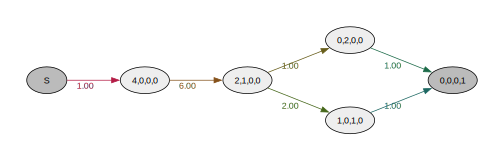

In [4]:
nr_samples = 4

@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i + j + 1] += 1
            transitions.append([new, [state[i] * (state[j] - same) / (1 + same)]])
    return transitions

graph = Graph(coalescent_1param)
reward_matrix = graph.states().T
graph.plot()

## Theta estimater per popultation via MoM

In [5]:
# For hver population: subsample til n=4, beregn empirisk SFS,
# fit standard-coalescent via MoM og estimér theta = 1/Ne

def load_ktons(path, n_use=4, seed=0):
    df = pd.read_csv(path)
    df = df[df["nr_samples"] >= n_use].copy()
    rng = np.random.default_rng(seed)
    k = rng.hypergeometric(
        ngood=df["derived_count"].values,
        nbad=(df["nr_samples"] - df["derived_count"]).values,
        nsample=n_use,
    )
    return k[(k > 0) & (k < n_use)]

paths = {
    "Eastern yellow (Mikumi)": OUT_DIR / "derived_counts_yellow_east.csv",
    "Kinda":                   OUT_DIR / "derived_counts_kinda.csv",
    "Southern olive":          OUT_DIR / "derived_counts_olive_south.csv",
    "Western yellow (Mahale)": OUT_DIR / "derived_counts_yellow_west.csv",
    "Olive gog":               OUT_DIR / "derived_counts_olive_gog.csv",
}

theta_results = {}
for name, path in paths.items():
    k = load_ktons(path)
    # Brug reward-baseret MoM: matcher forventet branch-længde per bin
    rewards = reward_matrix[:-1]  # udelad 4-ton (absorberende)
    n_obs = len(k)
    n_feat = len(rewards)
    data_2d = np.full((n_obs * n_feat, n_feat), np.nan)
    for i, r in enumerate(rewards):
        obs_i = graph.sample(n_obs, rewards=r)
        data_2d[i*n_obs:(i+1)*n_obs, i] = obs_i

    # Enklere: brug bare gennemsnitlig coalesceringstid som moment
    from phasic import dense_to_sparse
    sparse = dense_to_sparse(data_2d)
    try:
        mom = graph.method_of_moments(sparse, rewards=rewards)
        theta_results[name] = {
            "theta": mom.theta[0],
            "std": mom.std[0],
            "Ne": (1/mom.theta[0]) * (pi_df.loc[name, "pi"] / (4 * MUT_RATE))
                  if name in pi_df.index else None,
        }
    except Exception as e:
        print(f"{name}: MoM fejlede — {e}")

theta_df = pd.DataFrame(theta_results).T
print("\nTheta-estimater per population:")
print(theta_df.round(4))

W0426 15:06:00.082083 2939330 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.



Theta-estimater per population:
                          theta     std          Ne
Eastern yellow (Mikumi)  0.9994  0.0009  71830.2664
Kinda                    1.0026  0.0009  79254.8348
Southern olive           0.9999  0.0011  54710.0860
Western yellow (Mahale)  0.9994  0.0009  79708.9123
Olive gog                0.9985  0.0011  48463.8683


## Forventet vs. observeret SFS per population 

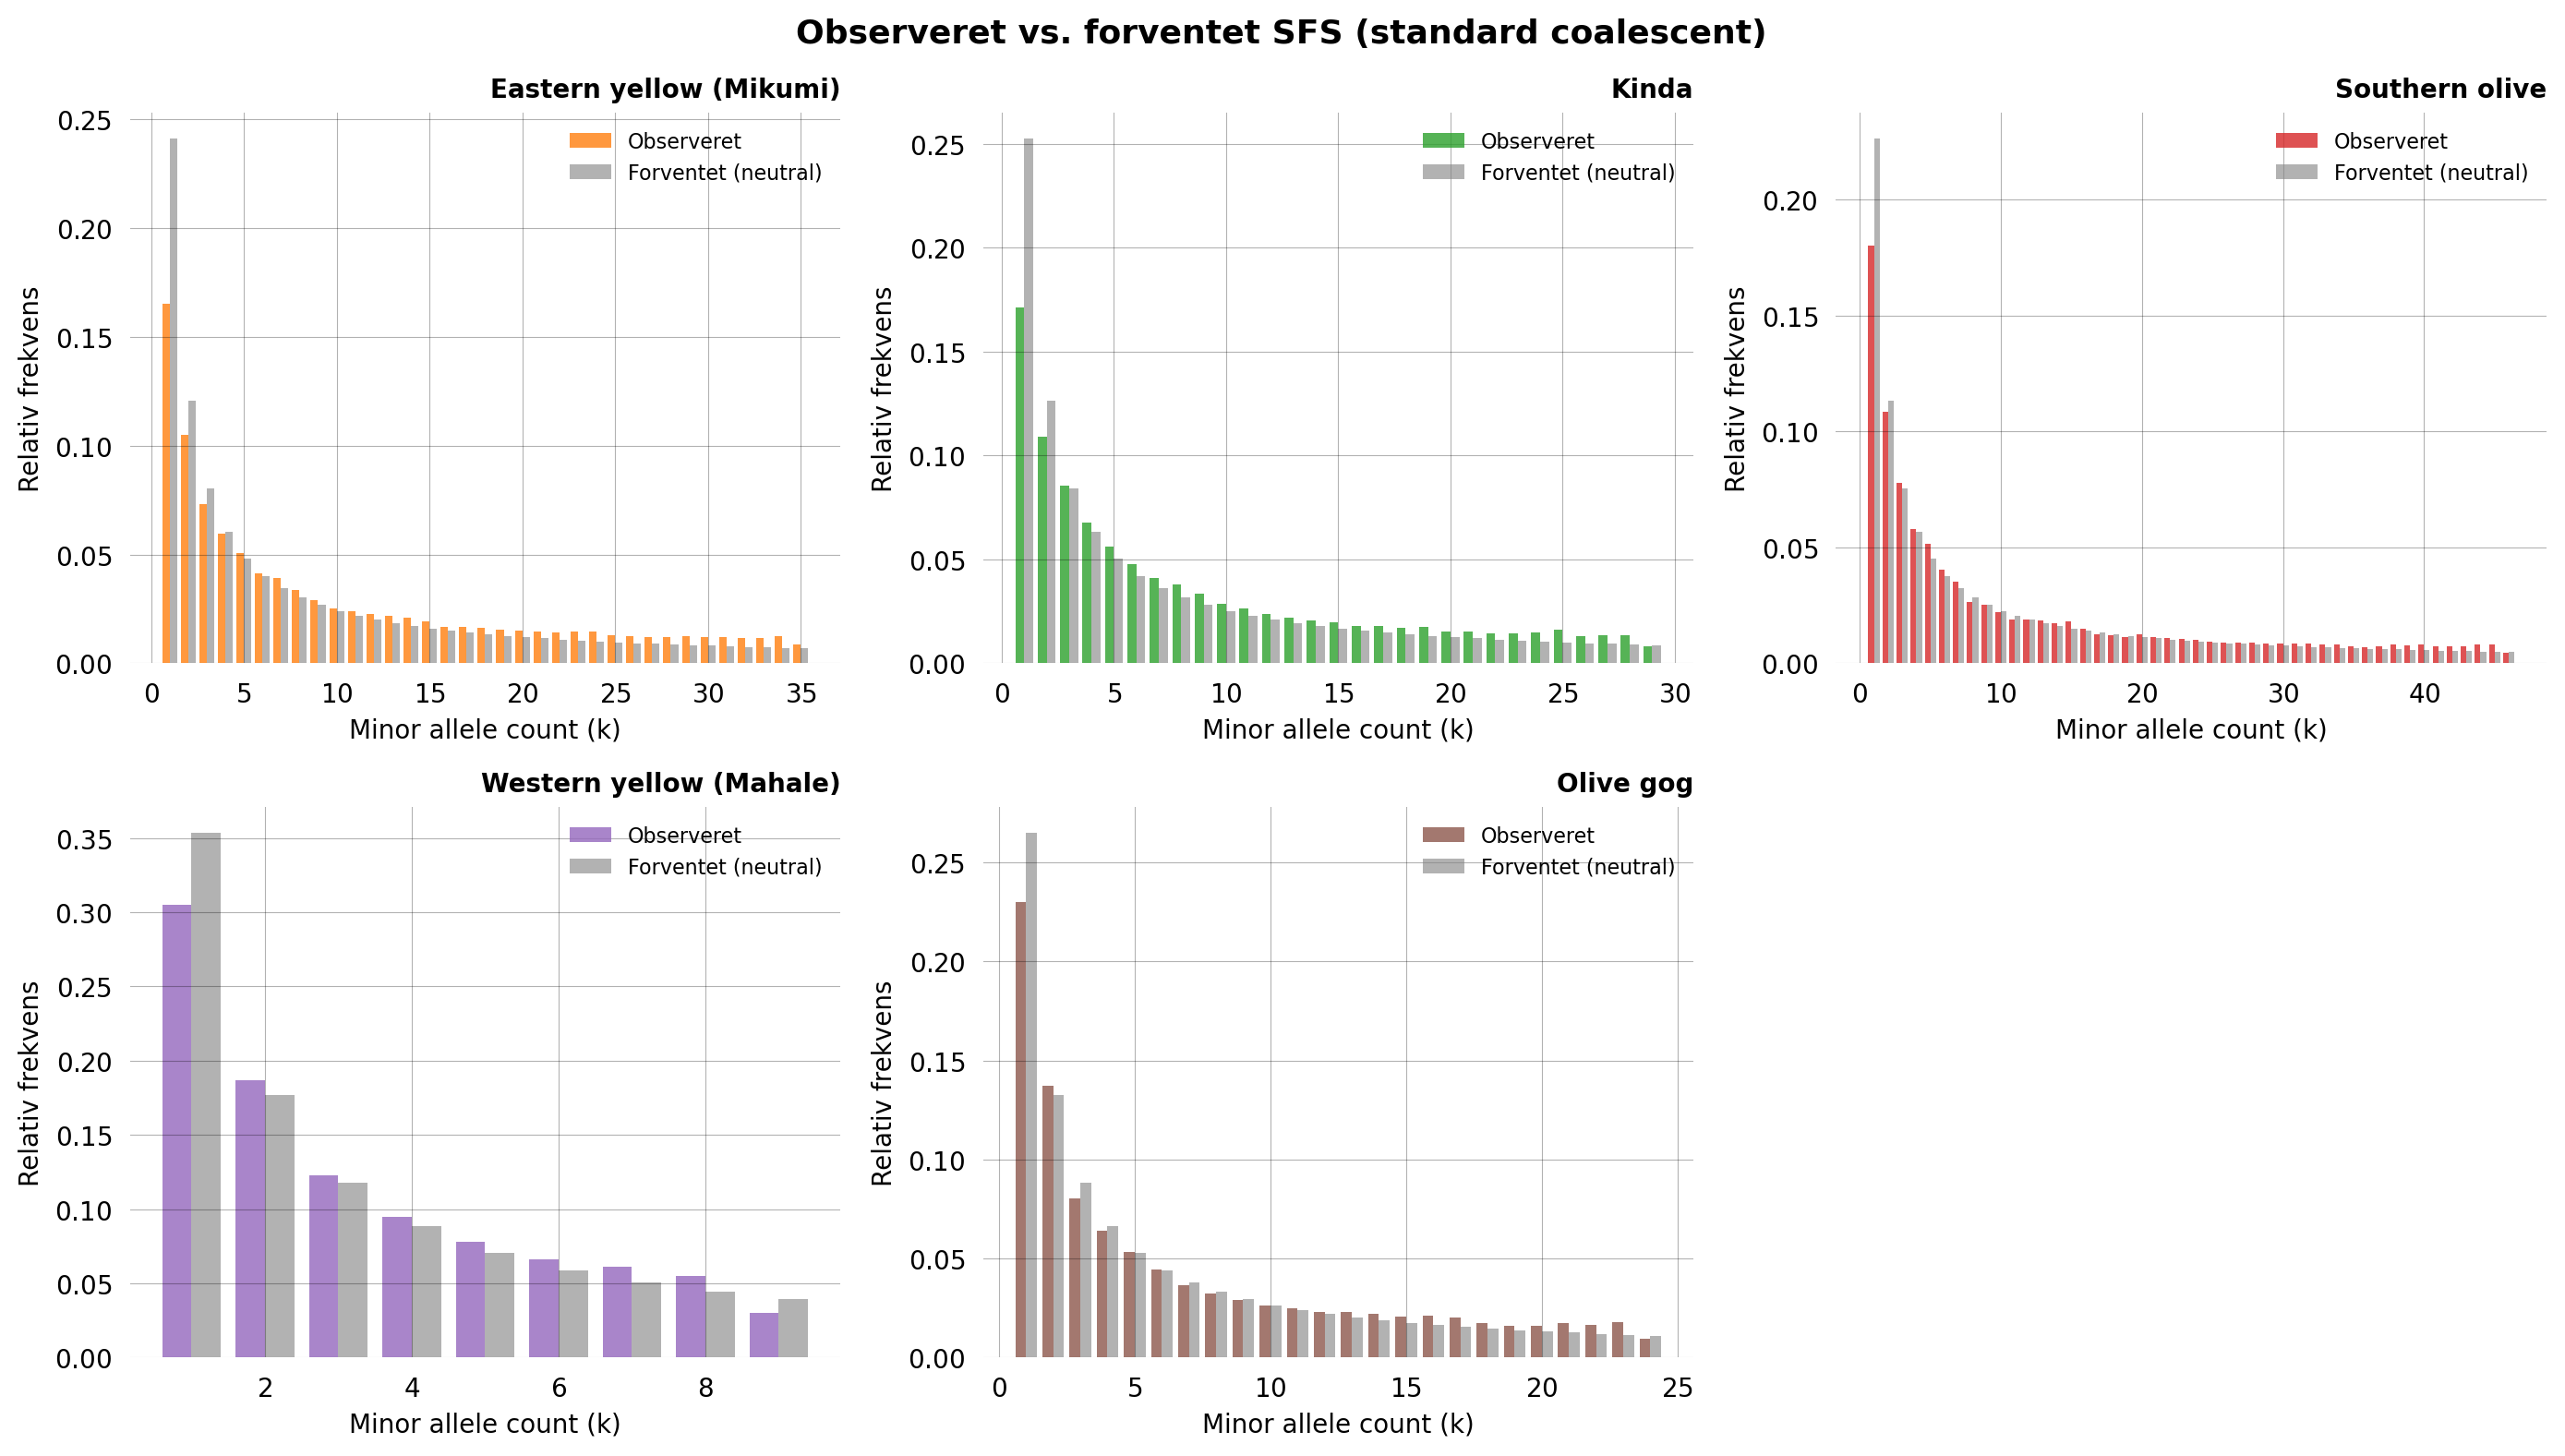

In [6]:
# For hver population: fit theta med MoM og sammenlign forventet SFS med observeret

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

pop_items = list(pop_names.items())
for ax_idx, (name, (df_pop, sfs_obs, color)) in enumerate(pop_items):
    ax = axes[ax_idx]
    pi_val = pi_df.loc[name, "pi"]
    Ne_ref = pi_val / (4 * MUT_RATE)

    # Theta fra pi: theta = 4*Ne*mu → Ne = pi/(4*mu)
    # Forventet SFS: E[SFS_k] = theta/k (standard coalescent)
    theta_pi = pi_val  # pi ≈ theta for panmiktisk population

    x = np.arange(1, len(sfs_obs) + 1)
    # Normaliser begge til frekvenser
    obs_norm = sfs_obs.values / sfs_obs.values.sum()
    exp_sfs = np.array([1/k for k in x])
    exp_norm = exp_sfs / exp_sfs.sum()

    ax.bar(x - 0.2, obs_norm, width=0.4, label="Observeret", color=color, alpha=0.8)
    ax.bar(x + 0.2, exp_norm, width=0.4, label="Forventet (neutral)", color="grey", alpha=0.6)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Minor allele count (k)")
    ax.set_ylabel("Relativ frekvens")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

# Fjern tom subplot
axes[-1].set_visible(False)
plt.suptitle("Observeret vs. forventet SFS (standard coalescent)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "sfs_obs_vs_expected.png", dpi=150, bbox_inches="tight")
plt.show()

## Tajima's D per population

In [7]:
# Tajima's D sammenligner pi (pairwise diversity) med Watterson's theta
# D > 0: overskud af common variants → balancerende selektion eller admixture
# D < 0: overskud af singletons → nylig ekspansion eller purifying selektion

def tajimas_d(df_pop, n=4):
    """
    Beregner Tajima's D for en population.
    Kræver derived count data og subsampler til n haplotyper.
    """
    rng = np.random.default_rng(0)
    k = rng.hypergeometric(
        ngood=df_pop["derived_count"].values,
        nbad=(df_pop["nr_samples"] - df_pop["derived_count"]).values,
        nsample=n,
    )
    k = k[(k > 0) & (k < n)]
    S = len(k)  # antal segregerende sites

    if S == 0:
        return np.nan, np.nan, np.nan

    # Watterson's theta_W = S / a1
    a1 = sum(1/i for i in range(1, n))
    theta_W = S / a1

    # Pi (gennemsnitlig pairwise differences)
    pi_val = sum(ki * (n - ki) for ki in k) * 2 / (n * (n-1))

    # Tajima's D (forenklet uden variansterm)
    # Fuld formel kræver b1, b2, c1, c2 korrektionstermerne
    b1 = (n + 1) / (3 * (n - 1))
    b2 = (2 * (n**2 + n + 3)) / (9 * n * (n - 1))
    c1 = b1 - 1/a1
    a2 = sum(1/i**2 for i in range(1, n))
    c2 = b2 - (n + 2)/(a1 * n) + a2/a1**2
    e1 = c1 / a1
    e2 = c2 / (a1**2 + a2)
    var_d = e1 * S + e2 * S * (S - 1)
    D = (pi_val - theta_W) / np.sqrt(var_d) if var_d > 0 else np.nan

    return D, pi_val, theta_W

tajima_results = {}
for name, (df_pop, _, _) in pop_names.items():
    D, pi_v, theta_w = tajimas_d(df_pop)
    tajima_results[name] = {"Tajima's D": round(D, 4), "pi": round(pi_v, 6), "theta_W": round(theta_w, 6)}

tajima_df = pd.DataFrame(tajima_results).T
print("Tajima's D per population:")
print(tajima_df)
print()
print("Fortolkning:")
print("  D ≈ 0:  konsistent med neutral evolution og konstant population")
print("  D > 0:  overskud af common variants (admixture, balancerende selektion, bottleneck)")
print("  D < 0:  overskud af singletons (nylig ekspansion, purifying selektion)")

Tajima's D per population:
                         Tajima's D             pi        theta_W
Eastern yellow (Mikumi)      0.0009  189245.500000  189230.181818
Kinda                       -0.0206  209844.833333  210255.818182
Southern olive              -0.0335  143659.000000  144118.363636
Western yellow (Mahale)     -0.0327  219016.833333  219700.909091
Olive gog                   -0.0235  128356.166667  128643.818182

Fortolkning:
  D ≈ 0:  konsistent med neutral evolution og konstant population
  D > 0:  overskud af common variants (admixture, balancerende selektion, bottleneck)
  D < 0:  overskud af singletons (nylig ekspansion, purifying selektion)


### Visualisering af Tajima's D

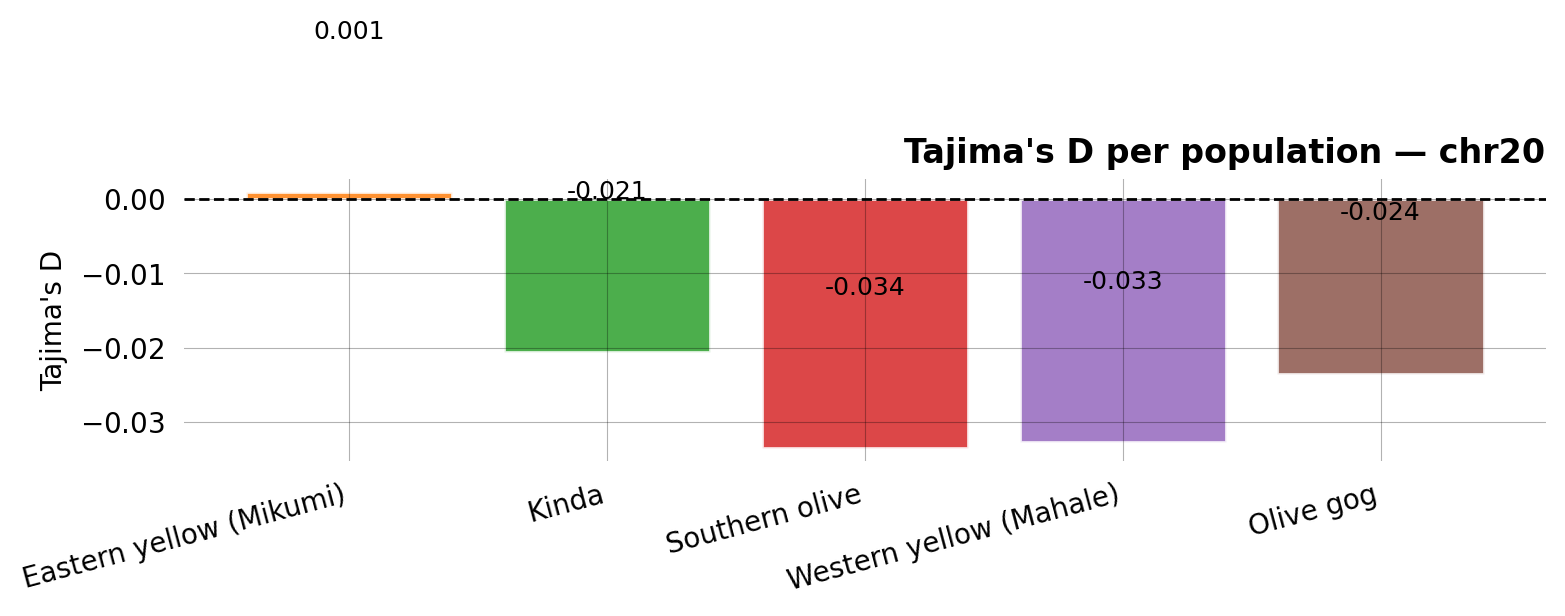

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["C1", "C2", "C3", "C4", "C5"]
bars = ax.bar(tajima_df.index, tajima_df["Tajima's D"], color=colors, alpha=0.85, edgecolor="white")
ax.axhline(0, color="black", lw=1, ls="--")
ax.set_ylabel("Tajima's D")
ax.set_title("Tajima's D per population — chr20", fontsize=12, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)

for bar, val in zip(bars, tajima_df["Tajima's D"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)

plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(OUT_DIR / "tajimas_d.png", dpi=150, bbox_inches="tight")
plt.show()

## Sammenligning af alle estimater i en tabel

In [9]:
summary = pd.DataFrame({
    "pi": pi_df["pi"],
    "Ne_ref": (pi_df["pi"] / (4 * MUT_RATE)).astype(int),
    "Tajima's D": tajima_df["Tajima's D"],
})
print("Samlet overblik per population:")
print(summary.round(6))

Samlet overblik per population:
                               pi  Ne_ref  Tajima's D
Eastern yellow (Mikumi)  0.002584   71788      0.0009
Kinda                    0.002861   79458     -0.0206
Southern olive           0.001969   54704     -0.0335
Western yellow (Mahale)  0.002868   79663     -0.0327
Olive gog                0.001742   48388     -0.0235


## Two-island model på Eastern Yellow vs. Kinda

In [10]:
# Genbyg modellen og kør inferens (husk: resultater fra NB 04 genbruges her)

indexer_2i = StateIndexer(
    lineages=[
        Property("descendants", min_value=1, max_value=nr_samples),
        Property("in_pop",      min_value=1, max_value=2),
    ]
)
ipv_2i = [0] * indexer_2i.state_length
ipv_2i[indexer_2i.lineages.props_to_index(descendants=1, in_pop=1)] = nr_samples

@with_ipv(ipv_2i)
def two_island(state, indexer=None):
    transitions = []
    if state.sum() <= 1:
        return transitions

    for i, j in all_pairs(indexer.lineages):
        pi = indexer.lineages.index_to_props(i)
        pj = indexer.lineages.index_to_props(j)
        if pi.in_pop != pj.in_pop: continue
        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy()
        new[i] -= 1; new[j] -= 1
        des = pi.descendants + pj.descendants
        if des > nr_samples: continue
        k = indexer.lineages.props_to_index(descendants=des, in_pop=pi.in_pop)
        new[k] += 1
        rate = state[i] * (state[j] - same) / (1 + same)
        coeff = [rate if pi.in_pop == 1 else 0, rate if pi.in_pop == 2 else 0, 0]
        transitions.append([new, coeff])

    for i in range(indexer.state_length):
        if state[i] == 0: continue
        pi = indexer.lineages.index_to_props(i)
        other = 2 if pi.in_pop == 1 else 1
        new = state.copy()
        new[i] -= 1
        k = indexer.lineages.props_to_index(descendants=pi.descendants, in_pop=other)
        new[k] += 1
        transitions.append([new, [0, 0, state[i]]])

    return transitions

graph_2i = Graph(two_island)

mutation_rate = 1.0
joint_graph_2i = graph_2i.joint_prob_graph(
    indexer_2i,
    reward_only=["descendants"],
    reward_limit=1,
    tot_reward_limit=2,
    mutation_rate=mutation_rate,
)

tbl_2i = joint_graph_2i.joint_prob_table()
defect_2i = 1 - tbl_2i['prob'].sum()
print(f"Two-island joint probability: {len(tbl_2i)} mønstre, defekt={defect_2i.item():.4f}")

Exception raised in callback function


AttributeError: 'NoneType' object has no attribute 'lineages'

## Indlæs eastern yellow og kør SVGD

In [ ]:
k_east = load_ktons(OUT_DIR / "derived_counts_yellow_east.csv", n_use=nr_samples)
feature_cols = [c for c in tbl_2i.columns if c.startswith("descendants")]
allowed = set(tuple(int(x) for x in r) for r in tbl_2i[feature_cols].values)
obs_east = []
for k in k_east:
    o = [0] * len(feature_cols)
    if 0 < k - 1 < len(o):
        o[k - 1] = 1
    if tuple(o) in allowed:
        obs_east.append(o)

print(f"Eastern yellow: {len(obs_east):,} brugbare observationer")

rng = np.random.default_rng(0)
use = [obs_east[i] for i in rng.choice(len(obs_east), min(5000, len(obs_east)), replace=False)]

svgd_2i = joint_graph_2i.svgd(
    observed_data=use,
    fixed=[(3, mutation_rate)],
    n_iterations=150,
    n_particles=80,
    prior=[GaussPrior(ci=[0.1, 5.0]), GaussPrior(ci=[0.1, 5.0]),
           GaussPrior(ci=[0.0, 3.0]), None],
    learning_rate=ExpStepSize(first_step=0.08, last_step=0.01, tau=40.0),
)

print("\nTwo-island model — Eastern yellow (Mikumi):")
svgd_2i.summary(ci_method="hpd", ci_level=0.95)

### Fortolkning - Two-island model

In [ ]:
pi_east = pi_df.loc["Eastern yellow (Mikumi)", "pi"]
Ne_ref_east = pi_east / (4 * MUT_RATE)
res_2i = svgd_2i.get_results()
theta_2i = res_2i["theta_mean"]

N1_est = (1 / theta_2i[0]) * Ne_ref_east
N2_est = (1 / theta_2i[1]) * Ne_ref_east
m_est  = theta_2i[2] / (2 * Ne_ref_east)

print(f"\nTwo-island biologisk fortolkning:")
print(f"  N_ref (fra pi):          {Ne_ref_east:,.0f}")
print(f"  N1 (Eastern yellow):     {N1_est:,.0f} individer")
print(f"  N2 (Kinda):              {N2_est:,.0f} individer")
print(f"  Migration (m):           {m_est:.2e} per lineage per generation")
print(f"\n  Sørensen et al. (2023): gene flow dokumenteret")

svgd_2i.plot_ci(ci_method="hpd")
plt.suptitle("Posterior CI — Eastern yellow (Two-island model)")
plt.savefig(OUT_DIR / "two_island_posterior_ci.png", dpi=150, bbox_inches="tight")
plt.show()

svgd_2i.plot_pairwise()
plt.suptitle("Posterior pairwise — Two-island model", y=1.02)
plt.savefig(OUT_DIR / "two_island_posterior_pairwise.png", dpi=150, bbox_inches="tight")
plt.show()

## IM-model på Southern olive vs. Eastern Yellow

In [ ]:
# Genbrug epoch-konstruktionen fra NB 05

N_PARAMS = 5
t_split = 1.0
epochs_im = [0.0, t_split]

indexer_im = StateIndexer(
    lineages=[
        Property("descendants", min_value=1, max_value=nr_samples),
        Property("in_pop",      min_value=1, max_value=2),
    ],
    slots=["epoch"],
)

ipv_im = [0] * indexer_im.state_length
ipv_im[indexer_im.props_to_index(descendants=1, in_pop=1)] = nr_samples

def add_epoch_im(graph, callback, epochs, epoch_idx, indexer):
    epoch = epochs[epoch_idx]
    stop_probs    = np.array(graph.stop_probability(epoch))
    accum_v_time  = np.array(graph.accumulated_occupancy(epoch))
    with np.errstate(invalid="ignore"):
        epoch_trans_rates = stop_probs / accum_v_time

    for i in range(1, graph.vertices_length() - 1):
        if np.isnan(epoch_trans_rates[i]): continue
        if graph.vertex_at(i).edges_length() == 0: continue
        vertex = graph.vertex_at(i)
        state  = vertex.state()
        if state[indexer.epoch] != epoch_idx - 1: continue
        sister_state = state.copy()
        sister_state[indexer.epoch] = epoch_idx
        child = graph.find_or_create_vertex(sister_state)
        coeff = np.zeros(graph.param_length())
        coeff[-1] = epoch_trans_rates[i]
        vertex.add_edge(child, coeff)

    graph.extend(callback, epochs=epochs, epoch_idx=epoch_idx, indexer=indexer)

def im_callback(state, epochs=None, epoch_idx=None, indexer=None):
    transitions = []
    epoch_idx = int(epoch_idx)
    if state[indexer.epoch] != epoch_idx: return transitions
    lineage_sum = sum(state[k] for k in range(indexer.state_length) if k != indexer.epoch)
    if lineage_sum <= 1: return transitions

    for i, j in all_pairs(indexer.lineages):
        pi = indexer.lineages.index_to_props(i)
        pj = indexer.lineages.index_to_props(j)
        if epoch_idx == 0 and pi.in_pop != pj.in_pop: continue
        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy(); new[i] -= 1; new[j] -= 1
        des = pi.descendants + pj.descendants
        if des > nr_samples: continue
        k = indexer_im.props_to_index(descendants=des, in_pop=pi.in_pop)
        new[k] += 1
        rate = state[i] * (state[j] - same) / (1 + same)
        coeff = np.zeros(N_PARAMS)
        coeff[0 if (epoch_idx == 0 and pi.in_pop == 1) else
              1 if (epoch_idx == 0 and pi.in_pop == 2) else 3] = rate
        transitions.append([new, coeff])

    if epoch_idx == 0:
        for i in range(indexer.state_length):
            if i == indexer_im.epoch or state[i] == 0: continue
            pi = indexer.lineages.index_to_props(i)
            other = 2 if pi.in_pop == 1 else 1
            new = state.copy(); new[i] -= 1
            k = indexer_im.props_to_index(descendants=pi.descendants, in_pop=other)
            new[k] += 1
            coeff = np.zeros(N_PARAMS); coeff[2] = state[i]
            transitions.append([new, coeff])

    return transitions

theta_init = [1.0, 0.5, 0.8, 0.7, 1.0]
graph_im = Graph(im_callback, ipv=ipv_im, epochs=epochs_im, epoch_idx=0, indexer=indexer_im)
graph_im.update_weights(theta_init)
add_epoch_im(graph_im, im_callback, epochs_im, 1, indexer_im)
graph_im.update_weights(theta_init)

print(f"IM-model: {graph_im.vertices_length()} tilstande, {graph_im.param_length()} parametre")

### IM joint probability graf

In [ ]:
mutation_rate_im = 1.0
joint_graph_im = graph_im.joint_prob_graph(
    indexer_im,
    reward_only=["descendants"],
    reward_limit=1,
    tot_reward_limit=2,
    mutation_rate=mutation_rate_im,
)
theta_joint_im = theta_init + [mutation_rate_im]
joint_graph_im.update_weights(theta_joint_im)

tbl_im = joint_graph_im.joint_prob_table()
defect_im = 1 - tbl_im['prob'].sum()
print(f"IM-model joint probability: {len(tbl_im)} mønstre, defekt={defect_im.item():.4f}")

MUT_IDX_IM    = joint_graph_im.param_length() - 1
EPOCH_IDX_IM  = MUT_IDX_IM - 1
fixed_im = [(EPOCH_IDX_IM, 1.0), (MUT_IDX_IM, mutation_rate_im)]
prior_im = ([GaussPrior(ci=[0.1, 5.0])] * 4 + [None, None])[:joint_graph_im.param_length()]

In [ ]:
# Kør SVGD på southern olive
k_oliv = load_ktons(OUT_DIR / "derived_counts_olive_south.csv", n_use=nr_samples)
feature_cols_im = [c for c in tbl_im.columns if c.startswith("descendants")]
allowed_im = set(tuple(int(x) for x in r) for r in tbl_im[feature_cols_im].values)
obs_oliv = []
for k in k_oliv:
    o = [0] * len(feature_cols_im)
    if 0 < k - 1 < len(o): o[k-1] = 1
    if tuple(o) in allowed_im: obs_oliv.append(o)

rng2 = np.random.default_rng(1)
use_oliv = [obs_oliv[i] for i in rng2.choice(len(obs_oliv), min(5000, len(obs_oliv)), replace=False)]
print(f"Southern olive: {len(use_oliv):,} observationer til SVGD")

svgd_im = joint_graph_im.svgd(
    observed_data=use_oliv,
    fixed=fixed_im,
    n_iterations=150,
    n_particles=80,
    prior=prior_im,
    learning_rate=ExpStepSize(first_step=0.06, last_step=0.01, tau=40.0),
)
print("\nIM-model — Southern olive:")
svgd_im.summary(ci_method="hpd", ci_level=0.95)

### Fortolkning IM-modellen 

In [ ]:
pi_oliv = pi_df.loc["Southern olive", "pi"]
Ne_ref_oliv = pi_oliv / (4 * MUT_RATE)
res_im = svgd_im.get_results()
theta_im = res_im["theta_mean"]

N1_im = (1 / theta_im[0]) * Ne_ref_oliv
N2_im = (1 / theta_im[1]) * Ne_ref_oliv
Na_im = (1 / theta_im[3]) * Ne_ref_oliv
m_im  = theta_im[2] / (2 * Ne_ref_oliv)
t_split_years = epochs_im[1] * 2 * Ne_ref_oliv * GEN_TIME

print(f"\nIM-model biologisk fortolkning:")
print(f"  N_ref (fra pi):           {Ne_ref_oliv:,.0f}")
print(f"  N1 (Southern olive):      {N1_im:,.0f} individer")
print(f"  N2 (Eastern yellow):      {N2_im:,.0f} individer")
print(f"  N_ancestral:              {Na_im:,.0f} individer")
print(f"  Migration (m):            {m_im:.2e} per lineage per generation")
print(f"  Split-tid:                {t_split_years:,.0f} år")
print()
print(f"  Sammenlign: Sørensen et al. (2023) estimerer split ~1 mio. år siden")

svgd_im.plot_ci(ci_method="hpd")
plt.suptitle("Posterior CI — Southern olive (IM-model)")
plt.savefig(OUT_DIR / "im_posterior_ci.png", dpi=150, bbox_inches="tight")
plt.show()

svgd_im.plot_pairwise()
plt.suptitle("Posterior pairwise — IM-model", y=1.02)
plt.savefig(OUT_DIR / "im_posterior_pairwise.png", dpi=150, bbox_inches="tight")
plt.show()

## Samlet resultat

In [ ]:
print("=" * 60)
print("SAMLET OVERBLIK — BAVIAN RESULTATER")
print("=" * 60)
print()
print("Populationskarakteristik:")
print(summary.round(4).to_string())
print()
print("\nTwo-island model (Eastern yellow):")
print(f"  N1:     {N1_est:,.0f}   N2:    {N2_est:,.0f}   m: {m_est:.2e} /gen")
print()
print("IM-model (Southern olive vs. Eastern yellow):")
print(f"  N1:     {N1_im:,.0f}   N2:    {N2_im:,.0f}")
print(f"  N_anc:  {Na_im:,.0f}   m:     {m_im:.2e} /gen")
print(f"  Split:  {t_split_years:,.0f} år  (Sørensen et al.: ~1 mio. år)")